# Домашняя работа №3

**Disclaimer**: 

Для каждой домашней работы обозначаются мягкие и жесткие дедлайны. За каждый день просрочки после мягкого дедлайна снимается 20% от оценки.

После жёсткого дедлайна работы не принимаются. Даже при опоздании на одну секунду. Сдавайте заранее.

Cтудент может 1 раз сдать домашнее задание после мягкого дедлайна (но до жёсткого) без штрафов.

В случае использования больших языковых моделей (large language models (LLMs), к примеру: ChatGPT, GigaChat, Qwen, etc):
- В chunk (ячейку) выше кода, созданного LLM, прикрепляйте промпт, который использовался для генерации.
- Отдельно опишите как подбирали промпты, какие заметили преимущества и недостатки GenAI для данного задания.
- За решение с указанным промптом - _штраф 40%_ для конкретного задания, который может быть пересмотрен в сторону увеличения в следующих случаях: 
    - использован ответ LLM без указания промпта _(штраф 100%)_
    - решение избыточно и, или написано неоптимально (использование magic команд без необходимости, использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, etc) _(штраф 50%)_

Также: 
- Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
- Мы в любом случае оставляем за собой право пригласить студента для защиты своего ДЗ, если заподозрим плагиат.

## Часть 1

## Prerequirements

```
pip install torch torchvision numpy matplotlib
```

In [1]:
# https://stackoverflow.com/a/60658965/7286121

from IPython.core.magic import register_cell_magic

@register_cell_magic
def write_and_run(line, cell):
    argz = line.split()
    file = argz[-1]
    mode = 'w'
    if len(argz) == 2 and argz[0] == '-a':
        mode = 'a'
    with open(file, mode) as f:
        f.write(cell)
    get_ipython().run_cell(cell)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt

### Hello, MNIST

Прежде чем собирать сеть, давайте определим инстансы класса `Dataset`, которые будут возвращать примеры из тренировочной и валидационной выборок.  
С помощью ячейки ниже, мы скачаем датасет [MNIST](http://yann.lecun.com/exdb/mnist/) в текущую директорию и сможем получать примеры из соответствующих объектов.

In [3]:
transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = MNIST(root = './', train = True, download = True, transform = transform_to_tensor)
mnist_val = MNIST(root = './', train = False, download = True, transform = transform_to_tensor)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:10<00:00, 924kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 145kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 1.87MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.31MB/s]


Посмотрим на несколько примеров из тренировочной выборки

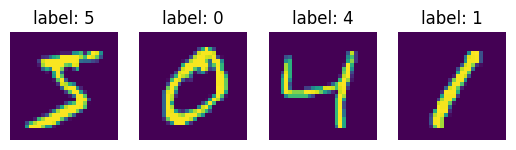

In [4]:
def show_examples(dataset: Dataset, num_examples: int = 4):
    fig, ax = plt.subplots(1, num_examples)
    
    for i in range(num_examples):
        img, label = dataset[i]
        ax[i].imshow(img[0])
        ax[i].set_title(f'label: {label}')
        ax[i].axis('off')
    plt.show()
    
    
show_examples(dataset = mnist_train)

### Задача 1
Напишите свою версию датасета, который будет читать картинки с диска.  
Подразумевается, что если вы написали свой датасет, то он будет использоваться при обучении вместо дефолтного `MNIST`.  

В ячейках ниже должен сгенериться датасет в таком формате:
- /MNIST_image_folder
    - /train.csv
    - /train/{class_name}/{image_name}.png
    - /val.csv
    - /val/{class_name}/{image_name}.png

CSV файлы содержат название файла и его лейбл: `image`, `label`.

*Hint 1:* нужно унаследоваться от класса `Dataset` и переопределить методы `__getitem__` и `__len__`.
Первый должен возвращать картинку и ее лейбл, а второй количество примеров в датасете.
(На самом деле второй метод не обязателен для самого датасета, но он необходим для
[семплера](https://pytorch.org/docs/stable/data.html#torch.utils.data.RandomSampler),
который используется даталоадером)
(см. [PyTorch docs](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset),
[PyTorch tutorual](https://pytorch.org/tutorials/recipes/recipes/custom_dataset_transforms_loader.html?highlight=dataset))  
*Hint 2:* для работы с картинками лучше использовать OpenCV: `pip install opencv-python-headless`.
В частности [cv2.imread](https://docs.opencv.org/master/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56).  
*Hint 3:* обратите особое внимание на то, что возвращает функция `cv2.imread`


In [5]:
import pickle
import numpy as np
import os
import cv2
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

def generate_image_folder_dataset(dataset, target_path, csv_path):
    images_counter = Counter()
    files = []
    labels = []
    for image, label in tqdm(dataset):
        class_folder = target_path + "/" + str(label)
        if not os.path.exists(class_folder):
            os.makedirs(class_folder, exist_ok = True)
    #todo
    pd.DataFrame({ "image": files, "label": labels }).to_csv(csv_path, index = False)

In [ ]:
generate_image_folder_dataset( mnist_train,  "./MNIST_image_folder/train", "MNIST_image_folder/train.csv" )
generate_image_folder_dataset( mnist_val,  "./MNIST_image_folder/val", "MNIST_image_folder/val.csv" )

Теперь можно написать свой класс датасета для тех файлов, которые мы сгенерили

### Задача 1 (20%)

In [ ]:
%%write_and_run dataset_mnist.py 

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2

class DatasetMNIST(Dataset):
    def __init__(self, root='./MNIST_image_folder', train = True, transform = None):
        pass

    def __len__(self):
        pass

    def __getitem__(self, index):
        # load image
        # transform image
        # return dict with image and class label

        # todo
        pass

тест класса датасета

In [ ]:
def test_dataset(dataset, test_name = "") :

    assert len(dataset) > 0, f"{test_name}: dataset length is greater then zero"

    idateset = iter(dataset)
    item = next(idateset)

    assert isinstance(item, dict), f"{test_name}: dataset returned dict"
    assert "image" in item, f"{test_name}: dataset item dict has image"
    assert "label" in item, f"{test_name}: dataset item dict has label"

    assert item['image'].shape == (1, 28, 28), f"{test_name}: dataset image shape is correct. Got: {item['image'].shape}"

mydataset = DatasetMNIST(train = False, transform = transform_to_tensor)
test_dataset(mydataset, test_name = "val")

mydataset = DatasetMNIST(train = True, transform = transform_to_tensor)
test_dataset(mydataset, test_name = "train")

### Задача 2 (40%)
Напишите класс CNN сети из 3 сверточных слоев.

*Hint 1:* на вход все те же батчи размера [BS, C, H, W]  
*Hint 2:* описание сверточных слоев [PyTorch docs](https://pytorch.org/docs/stable/nn.html#convolution-layers). Нам нужен `Conv2d`

Тут тоже можете поэксперементировать с разными слоями активации.

Чтобы было проще считать размерности для конечного слоя, используйте `kernel_size = 3, padding = 1` в сверточных слоях

In [ ]:
%%write_and_run custom_cnn.py 

# важно! все зависимости, которые используете (если добавляее новые) в этом классе надо явно продублировать в эту ячейку
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        pass

    def forward(self, x):
        pass

    def compute_all(self, batch):  # удобно сделать функцию, в которой вычисляется лосс по пришедшему батчу

        pass

### Задача 3 (40%)
Инициализируйте и обучите сеть из пункта  2

В trainer'e, возможно, вы захотите писать больше метрик: лосс во время трейна, валидационный лосс, валидационные метрики (можно префиксовать валидационные метрики с помощью "val", чтобы не путались)

(!) Модель должна побить определенные пороги кач-ва (> 0.8 за 3 эпохи)

In [ ]:
from torch.utils.tensorboard import SummaryWriter

class Trainer:
    def __init__(self, model, optimizer, train_dataset, val_dataset, batch_size=128):
        pass

#### CustomCNN

In [ ]:
model = CustomCNN()
opt = optim.SGD(model.parameters(), lr = 3e-3)

mnist_train = DatasetMNIST(train = True, transform = transform_to_tensor)
mnist_val = DatasetMNIST(train = False, transform = transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [ ]:
trainer.train(3)
torch.save(model.state_dict(), "custom_cnn.pt")  # важно сохранить веса обученой модели!

### Тест


In [ ]:
import pytest
import torch
import torch.nn as nn

import sys

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

mnist_val = MNIST(root = './', train = False, download = True, transform = transform_to_tensor)

def _test_model(model, target_accuracy, flatten=True):
    print(model)

    dataloader = DataLoader(mnist_val, batch_size=128)

    all_logits = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:
            if flatten:
                images = images.flatten(1)
            logits = model(images)
            all_logits.append(logits)
            all_labels.append(labels)

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)

        print(all_logits.shape, all_labels.shape)

        accuracy = (all_logits.argmax(axis=1) == all_labels).float().mean().cpu().numpy()
        print("accuracy", accuracy)

        assert accuracy > target_accuracy



def test_model_cnn():
    from custom_cnn import CustomCNN

    ccnn = CustomCNN()
    ccnn.load_state_dict( torch.load("custom_cnn.pt") )
    ccnn.eval()

    _test_model(ccnn, 0.8, flatten = False)





test_model_cnn()


#### Не забываем смотреть в тензорборд

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir ./tmp